<a href="https://colab.research.google.com/github/HarishBankai/SY-IAI/blob/main/28001_IAI_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shortest path found: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]


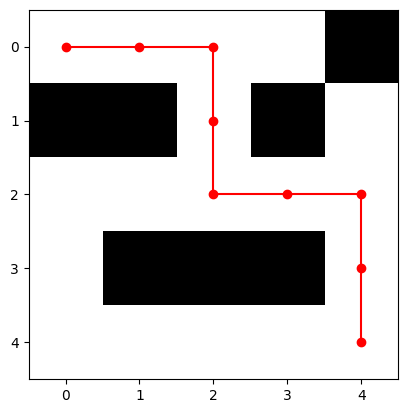

In [16]:
import heapq
import matplotlib.pyplot as plt

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def a_star(grid, start, goal):
    rows, cols = len(grid), len(grid[0])
    open_list = []
    heapq.heappush(open_list, (0, start))
    came_from = {}
    g_cost = {start: 0}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        for d in directions:
            neighbour = (current[0] + d[0], current[1] + d[1])
            if (0 <= neighbour[0] < rows and
                0 <= neighbour[1] < cols and
                grid[neighbour[0]][neighbour[1]] == 0):

                tentative_g_cost = g_cost[current] + 1
                if neighbour not in g_cost or tentative_g_cost < g_cost[neighbour]:
                    g_cost[neighbour] = tentative_g_cost
                    f_cost = tentative_g_cost + heuristic(neighbour, goal)
                    heapq.heappush(open_list, (f_cost, neighbour))
                    came_from[neighbour] = current
    return None

warehouse = [[0, 0, 0, 0, 1], [1, 1, 0, 1, 0], [0, 0, 0, 0, 0], [0, 1, 1, 1, 0], [0, 0, 0, 0, 0]]
start, goal = (0, 0), (4, 4)
path = a_star(warehouse, start, goal)

if path:
    print("Shortest path found:", path)
    plt.imshow(warehouse, cmap='Greys')
    plt.plot([p[1] for p in path], [p[0] for p in path], marker='o', color='red')
    plt.show()
else:
    print("No path found")